# Feature Engineering Assignment

### Student Details

| Field | Details |
|------|---------|
| **Name** | Pradeep B |
| **Student ID** | 2025EM1300180 |
| **Submission Date** | 8 August 2026 |
| **Dataset** | Employee Attrition Dataset |
| **Target** | Attrition |


---

## Objective

The objective of this assignment is to transform a raw employee dataset into a machine learning-ready dataset through a structured feature engineering workflow. The process includes data understanding, quality assessment, preprocessing, feature construction, feature selection, dimensionality reduction evaluation, and development of a reusable preprocessing pipeline.

The target variable for prediction is:

**Attrition** → Predict whether an employee is likely to leave the organisation.

---

## Feature Engineering Workflow

The following end-to-end workflow is implemented:

```
Data Understanding
        ↓
Data Quality Assessment(Missing Values | Outliers | Skewness | Correlation)
        ↓
Data Preprocessing(Imputation | Transformation | Encoding | Scaling)
        ↓
Feature Construction(Business-driven Feature Creation)
        ↓
Feature Selection(Correlation Analysis | Redundancy Removal)
        ↓
Dimensionality Reduction Evaluation(PCA)
        ↓
Reusable ML Pipeline(Preprocessing + Classification Model)
        ↓
Model Validation
```

---

## Key Assumptions

- The dataset represents employee-related information relevant for attrition analysis.
- Missing numerical values are assumed to be handled using statistical imputation methods without introducing significant bias.
- Categorical variables are assumed to require encoding before machine learning modelling.
- Feature selection decisions are based on statistical analysis combined with business intuition.
- The predictive model is used only to validate the effectiveness of the engineered feature set and preprocessing workflow; model accuracy optimisation is outside the scope of this assignment.

---

## Expected Outcome

The final outcome is a clean, interpretable, and reusable feature engineering pipeline that converts raw employee data into a format suitable for machine learning-based attrition prediction.

In [150]:
# Import all necessary Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Feature Selection
from sklearn.feature_selection import VarianceThreshold

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Display Settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [151]:
# Load Dataset
df = pd.read_csv(r"C:\Users\prbandar\OneDrive - Capgemini\Documents\BITS\FE\Graded Assignment Dataset.csv")

print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (5000, 39)


,Employee_ID,Age,Gender,Marital_Status,Education_Level,Department,Job_Role,Total_Work_Experience,Years_at_Company,Years_in_Current_Role,Promotion_Count,Business_Travel,Work_Mode,Distance_From_Home,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Annual_Compensation,Experience_Band,Attrition
0,EMP100001,37,Male,Single,Bachelor,Engineering,Senior Engineer,15,7.8,5.0,2,Frequently,Hybrid,19.2,11032.61,17422.14,151484.41,4.7,5288.23,Medium,4,4.0,35.1,3,3,6,5,7.0,6,7,7,6.50,53.59,44.11,92.84,52.99,301297.87,Mid,0
1,EMP100002,27,Male,Single,Bachelor,Operations,Engineer,2,2.0,0.1,0,Never,Office,6.1,5953.93,14494.60,0.00,10.8,4232.64,Low,3,3.0,NaN,0,1,6,5,5.0,5,5,5,5.25,39.22,85.62,88.21,14.41,85941.76,Entry,0
2,EMP100003,41,Male,Married,Master,Finance,Manager,15,4.7,0.2,1,Frequently,Hybrid,4.9,22053.98,19612.16,232221.91,1.3,11040.13,High,3,4.0,31.8,0,8,6,4,6.0,4,9,4,5.75,49.53,36.18,90.69,36.18,516481.83,Mid,0
3,EMP100004,43,Male,Divorced,Bachelor,Finance,Manager,23,3.0,0.8,0,Never,Hybrid,15.0,27033.46,137192.60,111808.68,1.3,16966.09,High,4,5.0,31.6,0,8,6,6,5.0,6,6,8,6.50,59.97,50.70,89.36,31.91,573402.80,Senior,0
4,EMP100005,21,Male,Single,Bachelor,HR,Associate,0,0.0,0.0,0,Rarely,Hybrid,15.7,3253.53,4228.73,0.00,3.4,1435.83,Low,3,3.0,20.4,0,2,5,4,5.0,4,5,4,4.50,39.32,44.69,90.01,14.34,43271.09,Entry,0


# Part A – Understanding the Dataset

## Objective

Explore the employee attrition dataset to understand its structure, identify data quality issues, and examine the characteristics of the available features. The analysis focuses on understanding numerical and categorical variables, identifying missing values, outliers, skewed distributions, and relationships among variables that may influence subsequent feature engineering decisions. The insights obtained from this exploratory analysis will guide the design of an effective preprocessing pipeline for machine learning.

## A.1 Dataset Structure & Feature Summary

Understanding the structure of the dataset is the first step in the feature engineering process. This includes examining the size of the dataset, identifying feature data types, and summarizing the statistical characteristics of the variables. The objective is to understand the nature of the available features and identify any structural issues that may require preprocessing before feature engineering.

In [152]:
# Dataset Dimensions

print("Dataset Dimensions")
print("-" * 50)

print(f"Number of Records : {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

# Dataset Overview

print("-"*60)
print("Dataset Information")
print("-"*60)
df.info()

Dataset Dimensions
--------------------------------------------------
Number of Records : 5000
Number of Features: 39
------------------------------------------------------------
Dataset Information
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                5000 non-null   str    
 1   Age                        5000 non-null   int64  
 2   Gender                     5000 non-null   str    
 3   Marital_Status             5000 non-null   str    
 4   Education_Level            5000 non-null   str    
 5   Department                 5000 non-null   str    
 6   Job_Role                   5000 non-null   str    
 7   Total_Work_Experience      5000 non-null   int64  
 8   Years_at_Company           5000 non-null   float64
 9   Years_in_Current_Role  

In [153]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,34.978800,7.708530,21.00,29.0000,35.000,40.0000,60.00
Total_Work_Experience,5000.0,12.669800,7.955767,0.00,7.0000,12.000,18.0000,41.00
Years_at_Company,5000.0,3.410080,2.679753,0.00,1.4000,2.900,4.9000,17.10
Years_in_Current_Role,5000.0,1.715520,1.845140,0.00,0.4000,1.100,2.4000,15.80
Promotion_Count,5000.0,0.609200,0.763015,0.00,0.0000,0.000,1.0000,4.00
Distance_From_Home,5000.0,15.356100,12.337019,0.10,6.8000,12.200,20.2000,103.50
Monthly_Salary,5000.0,11999.927000,7942.839669,2420.45,6279.6375,10458.250,15533.0925,93069.80
Annual_Bonus,4700.0,36710.677534,36451.119511,176.62,13545.2750,25993.180,47960.6675,408826.73
Stock_Option_Value,5000.0,130869.447020,231877.594476,0.00,0.0000,0.000,203840.5050,2912175.45
Overtime_Hours,5000.0,8.974564,6.739951,0.10,4.2000,7.200,12.0250,54.21


In [154]:
# Feature Type Summary

numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"Total Features      : {df.shape[1]}")
print(f"Numerical Features  : {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Total Features      : 39
Numerical Features  : 29
Categorical Features: 10


## A.2 Numerical Feature Analysis

This section examines the distribution and relationships of numerical variables to identify patterns that may influence feature engineering. The analysis focuses on understanding the spread of numerical features, detecting skewed distributions, identifying potential outliers, and examining relationships between variables. These insights will support decisions regarding data transformation, scaling, outlier treatment, and feature selection in later stages of the preprocessing pipeline.

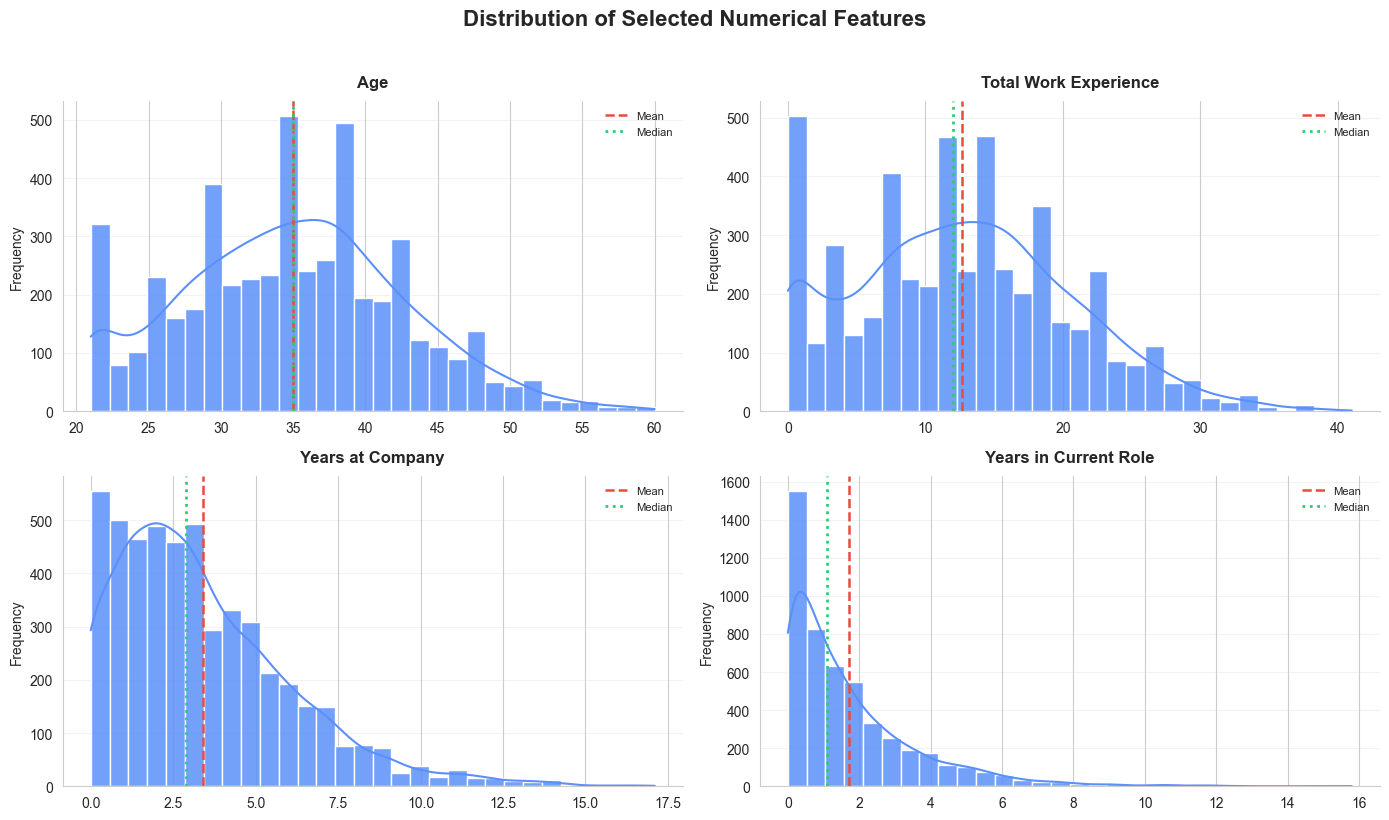

In [155]:
# Numerical Feature Analysis

top_num = df.select_dtypes(include=np.number).columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_num):
    sns.histplot(df[col], bins=30, kde=True, color="#5B8FF9",edgecolor="white", alpha=0.85, ax=ax)

    ax.axvline(df[col].mean(), color="#E74C3C", linestyle="--",linewidth=1.8, label="Mean")
    ax.axvline(df[col].median(), color="#2ECC71", linestyle=":",linewidth=2, label="Median")

    ax.set_title(col.replace("_", " "), fontsize=12, weight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", fontsize=8, frameon=False)

plt.suptitle("Distribution of Selected Numerical Features",fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

The histograms provide an overview of the distribution of key numerical variables across different aspects of employee information, including demographics, experience, compensation, workload, learning, engagement, and productivity. Variables exhibiting skewed distributions may require transformation, while approximately symmetric variables may only require scaling before model development.

In [156]:
# Skewness Analysis

skewness = (
    df.select_dtypes(include="number")
      .skew()
      .abs()
      .sort_values(ascending=False)
      .to_frame(name="Absolute Skewness")
)

skewness["Distribution"] = skewness["Absolute Skewness"].apply(
    lambda x: "Highly Skewed" if x > 1
    else "Moderately Skewed" if x > 0.5
    else "Approximately Symmetric"
)

skewness.head(15)

,Absolute Skewness,Distribution
Stock_Option_Value,3.380210,Highly Skewed
Annual_Bonus,3.060238,Highly Skewed
Annual_Compensation,2.163644,Highly Skewed
Monthly_Salary,2.142931,Highly Skewed
Years_in_Current_Role,1.923618,Highly Skewed
Distance_From_Home,1.895048,Highly Skewed
Overtime_Hours,1.611029,Highly Skewed
Monthly_Expenses,1.600538,Highly Skewed
Attrition,1.575932,Highly Skewed
Certification_Count,1.386466,Highly Skewed


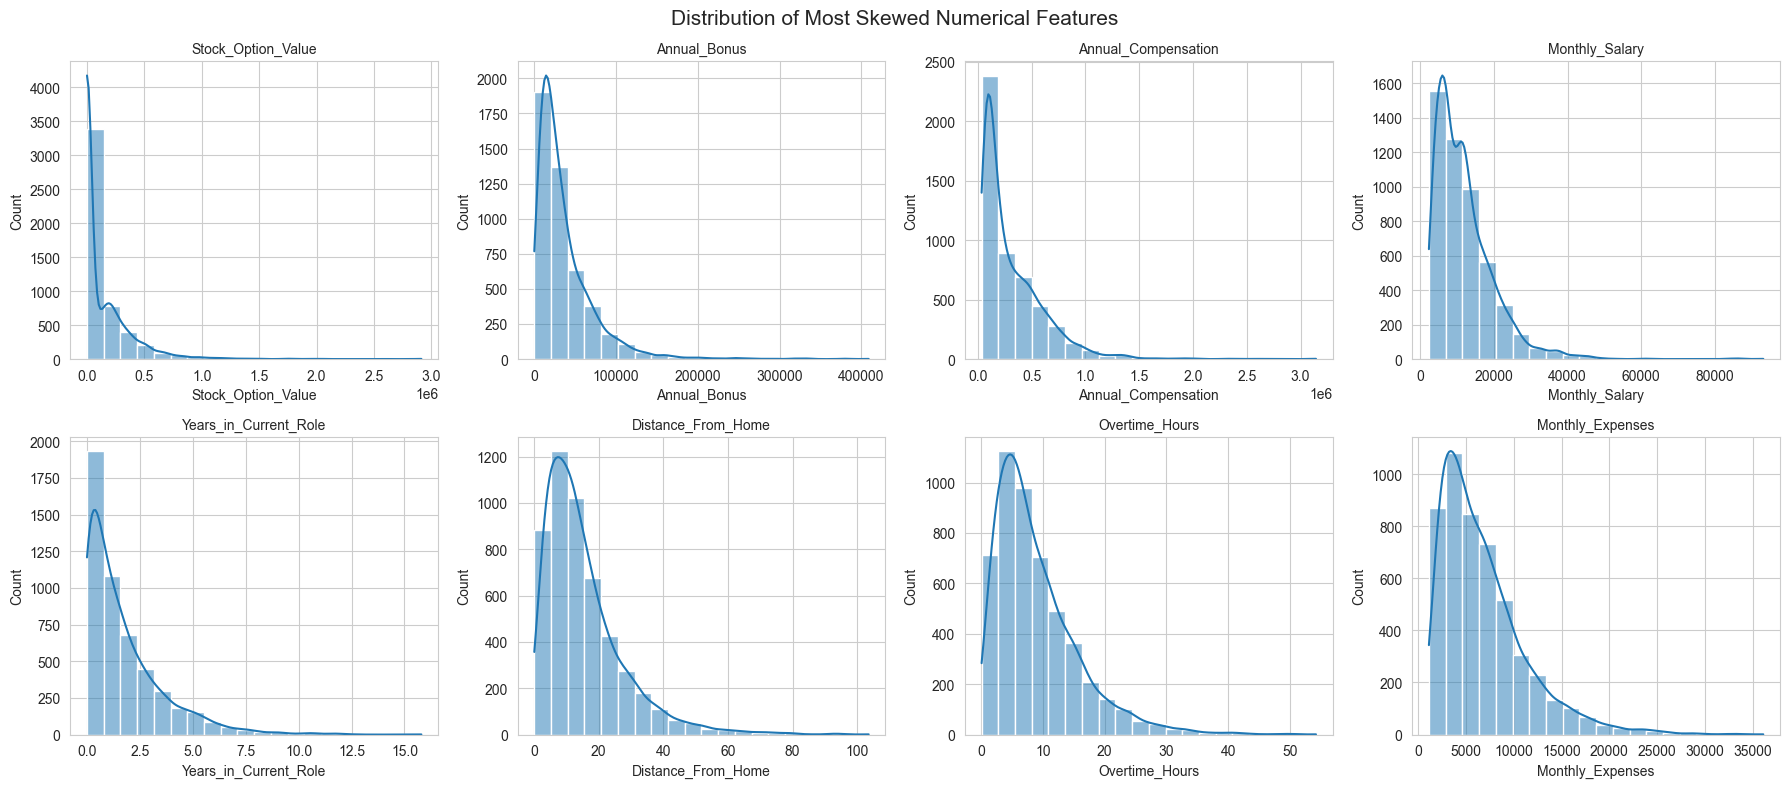

In [157]:
# Distribution of Top Skewed Features

top_features = skewness.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feature in zip(axes.ravel(), top_features):
    sns.histplot(df[feature], kde=True, bins=20, ax=ax)
    ax.set_title(feature, fontsize=10)

plt.suptitle("Distribution of Most Skewed Numerical Features", fontsize=15)
plt.tight_layout()
plt.show()

Skewness measures the symmetry of numerical feature distributions. Highly skewed variables may benefit from transformation techniques such as logarithmic or power transformations to reduce distributional imbalance and improve model performance. Features with low skewness generally require no transformation.

In [158]:
# Identify Features with Highest Number of Outliers (IQR Method)

outlier_count = {}

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_summary = (
    pd.DataFrame.from_dict(
        outlier_count,
        orient="index",
        columns=["Outlier Count"]
    )
    .sort_values("Outlier Count", ascending=False)
)

outlier_summary.head()

,Outlier Count
Attrition,953
Stock_Option_Value,316
Certification_Count,298
Annual_Bonus,261
Years_in_Current_Role,244


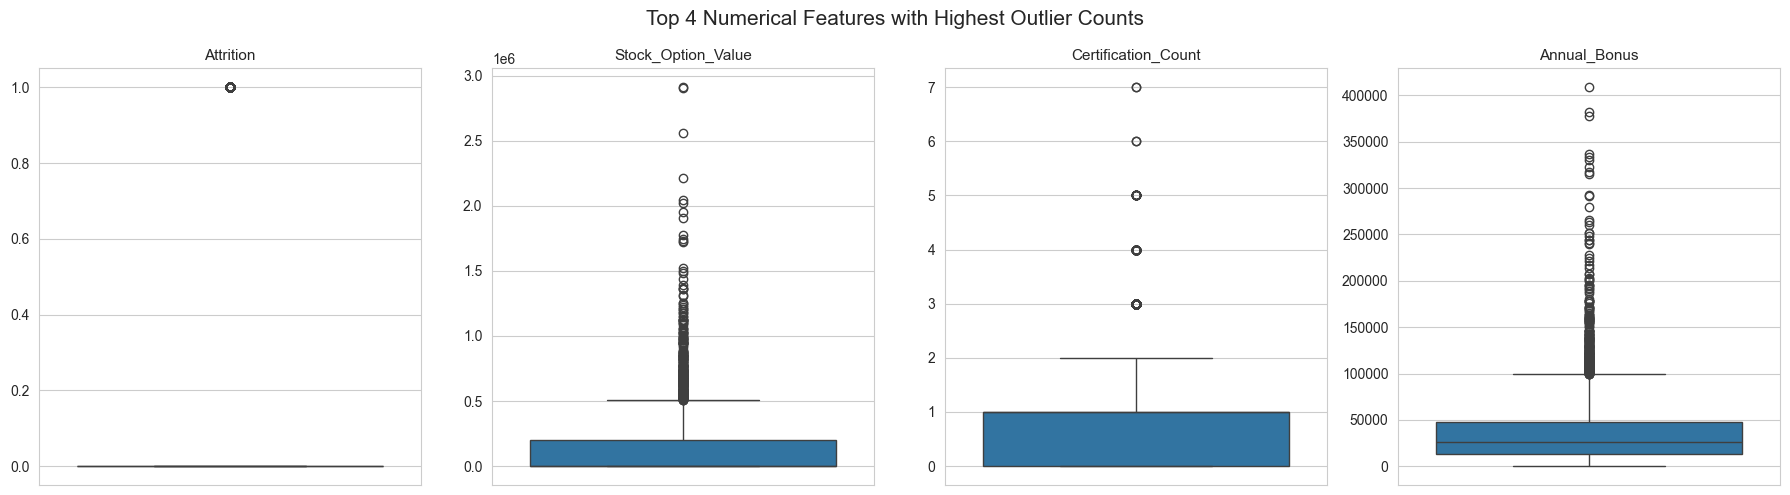

In [159]:
# Boxplots of Top 4 Features with Highest Outlier Counts

top_outlier_features = outlier_summary.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feature in zip(axes, top_outlier_features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(feature, fontsize=11)
    ax.set_ylabel("")

plt.suptitle("Top 4 Numerical Features with Highest Outlier Counts", fontsize=15)

plt.tight_layout()
plt.show()

The IQR-based analysis identified the numerical features containing the highest number of potential outliers. The boxplots confirm the presence of extreme observations within these variables.

However, in an HR dataset, extreme values do not necessarily represent data quality issues. Features such as compensation, work experience, and overtime may naturally contain legitimate extreme observations due to differences in employee roles, seniority, and responsibilities. Therefore, outlier treatment will be based on both statistical evidence and business context rather than removing all extreme values automatically.

### A.2.3 Correlation Analysis

Correlation analysis examines the strength and direction of relationships among numerical variables. Identifying highly correlated features is an important step in feature engineering, as redundant variables may increase model complexity without contributing additional information. The results of this analysis will guide later decisions on feature selection and dimensionality reduction.

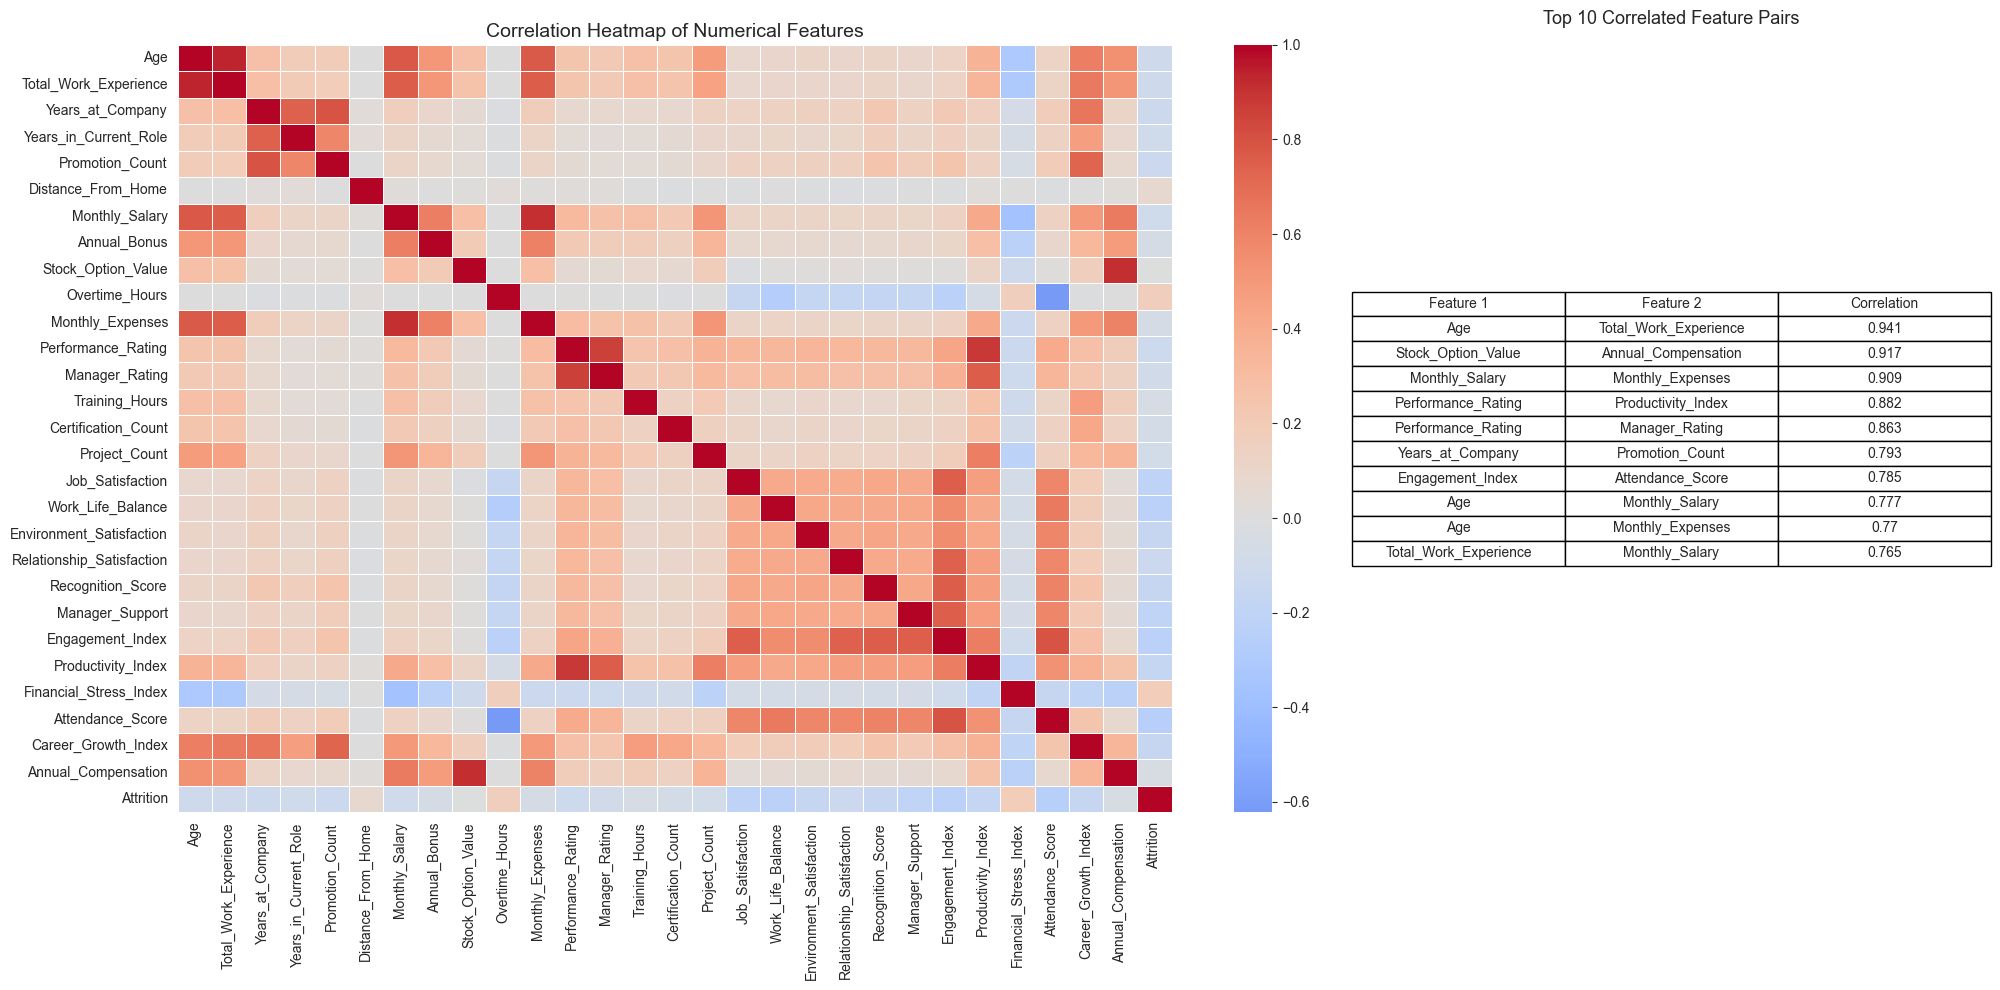

In [160]:
# Correlation Analysis

corr_matrix = df.select_dtypes(include='number').corr()

corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
corr_pairs["Absolute Correlation"] = corr_pairs["Correlation"].abs()

top_corr = (
    corr_pairs.sort_values("Absolute Correlation", ascending=False)
    [["Feature 1", "Feature 2", "Correlation"]]
    .head(10)
)

top_corr["Correlation"] = top_corr["Correlation"].round(3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10),
                               gridspec_kw={"width_ratios": [3.5, 1.5]})

sns.heatmap(corr_matrix, cmap="coolwarm", center=0,
            annot=False, linewidths=0.5, ax=ax1)

ax1.set_title("Correlation Heatmap of Numerical Features", fontsize=14)

ax2.axis("off")
ax2.set_title("Top 10 Correlated Feature Pairs", fontsize=13, pad=15)

table = ax2.table(cellText=top_corr.values,
                  colLabels=top_corr.columns,
                  cellLoc="center",
                  loc="center")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()

The correlation heatmap provides an overview of the relationships among numerical variables, while the ranked correlation table highlights the strongest feature pairs.

Highly correlated variables may contain overlapping information and could introduce redundancy into machine learning models. These relationships will be examined further during feature selection to determine whether certain variables should be retained, transformed, or removed. The correlation analysis will also help assess the suitability of dimensionality reduction techniques such as Principal Component Analysis (PCA).

## A.3 Data Quality Assessment

This section evaluates the overall quality of the dataset by identifying missing values and duplicate records. Understanding these issues is essential before feature engineering, as they may influence the choice of preprocessing techniques and affect the reliability of downstream machine learning models.

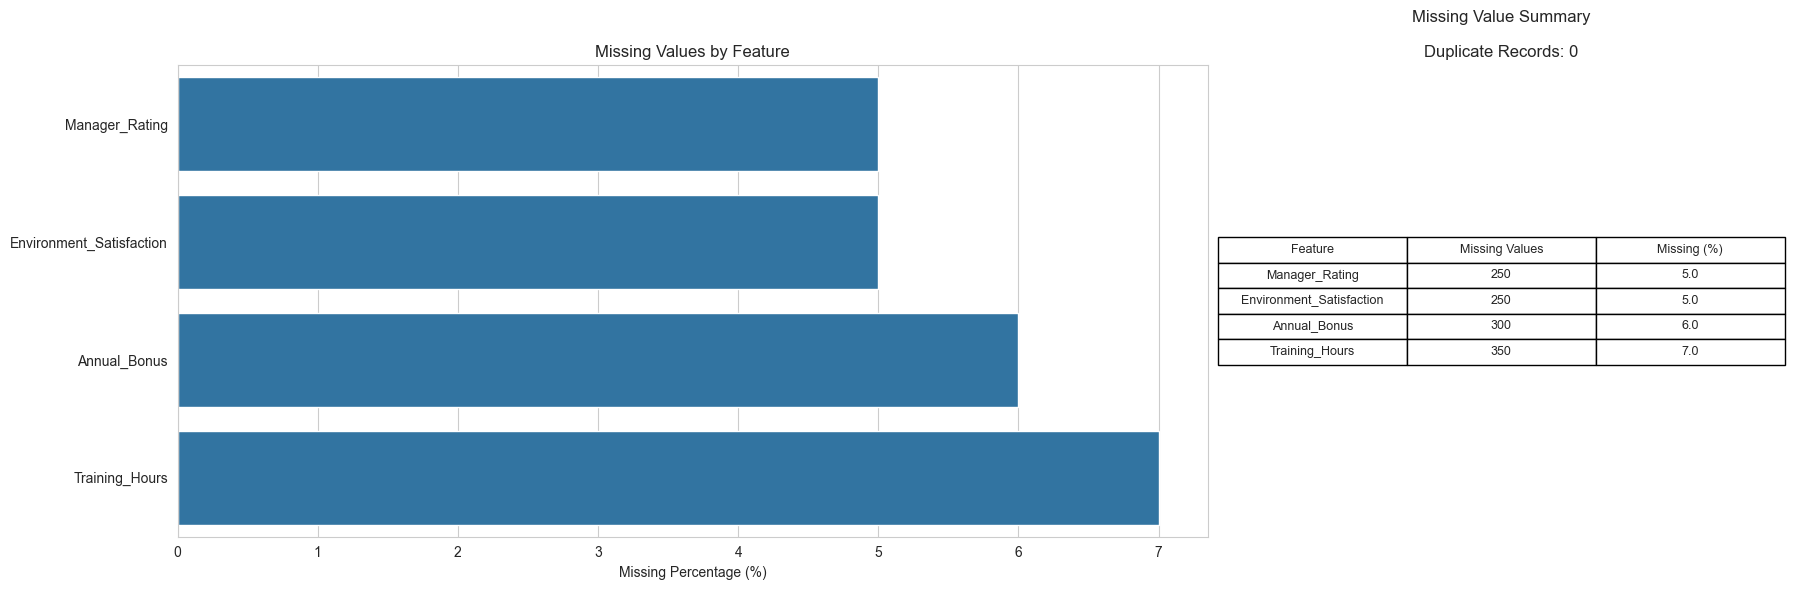

In [161]:
# Data Quality Assessment

missing = (
    df.isna()
      .sum()
      .to_frame("Missing Values")
      .assign(**{"Missing (%)": lambda x: (x["Missing Values"] / len(df) * 100).round(2)})
      .query("`Missing Values` > 0")
      .sort_values("Missing (%)")
      .reset_index()
      .rename(columns={"index": "Feature"})
)

duplicates = df.duplicated().sum()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [3, 1.5]}
)

# Missing Value Percentage Chart
sns.barplot(
    data=missing,
    x="Missing (%)",
    y="Feature",
    ax=ax1
)

ax1.set_title("Missing Values by Feature")
ax1.set_xlabel("Missing Percentage (%)")
ax1.set_ylabel("")

# Missing Summary Table
ax2.axis("off")

table = ax2.table(
    cellText=missing.values,
    colLabels=missing.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.5)

ax2.set_title(
    f"Missing Value Summary\n\nDuplicate Records: {duplicates}",
    fontsize=12
)

plt.tight_layout()
plt.show()

## A.4 Key Observations and Feature Engineering Implications

The exploratory data analysis provided insights into the characteristics, quality, and relationships present within the employee attrition dataset. These observations are used to guide the feature engineering strategy and preprocessing decisions applied in the following sections.

### Key Observations

- The dataset contains a combination of numerical, categorical, ordinal, and identifier features representing employee demographics, employment details, compensation, performance, and engagement information.

- Numerical variables show different distribution patterns, with some features exhibiting significant skewness. Skewed variables may require suitable transformations during preprocessing to improve model compatibility.

- Outlier analysis identified extreme observations in certain numerical variables. Since HR-related variables such as salary, experience, and overtime can naturally contain extreme values, outlier treatment should consider business context rather than removing all extreme values automatically.

- Correlation analysis identified strongly related numerical variables, suggesting the possibility of redundant features. These relationships will be considered during feature selection and dimensionality reduction.

- Missing values were identified in a limited number of features. Since missingness is relatively low, appropriate imputation strategies will be applied to preserve available employee information.

- Categorical variables contain meaningful employee attributes and will require appropriate encoding techniques before being used in machine learning models.

### Feature Engineering Decisions Influenced by EDA

Based on the above observations:

- Numerical features will undergo missing value imputation, scaling, and selective transformation where required.
- Categorical features will be encoded using suitable encoding techniques.
- Highly correlated or redundant features will be evaluated during feature selection.
- Outlier handling will be performed selectively based on feature characteristics and business interpretation.
- A reusable preprocessing pipeline will be developed to integrate all feature engineering steps.

# Part B – Designing a Feature Engineering Strategy

## Objective

The objective of this section is to transform the raw employee attrition dataset into a machine learning-ready dataset by applying appropriate feature engineering techniques. Based on the observations from Part A, missing values, numerical variables, and categorical features are preprocessed using suitable techniques, with each decision supported by technical justification.

## B.1 Missing Value Treatment

Missing values identified during the exploratory analysis are handled using appropriate imputation techniques to preserve the available information while minimizing the impact of incomplete observations on downstream machine learning models.

In [162]:
# Missing Value Treatment

df_fe = df.copy()

num_cols = df_fe.select_dtypes(include="number").columns
cat_cols = df_fe.select_dtypes(exclude="number").columns

df_fe[num_cols] = df_fe[num_cols].fillna(df_fe[num_cols].median())
df_fe[cat_cols] = df_fe[cat_cols].fillna(df_fe[cat_cols].mode().iloc[0])

pd.DataFrame({
    "Before": df.isna().sum(),
    "After": df_fe.isna().sum()
}).query("Before > 0")

,Before,After
Annual_Bonus,300,0
Manager_Rating,250,0
Training_Hours,350,0
Environment_Satisfaction,250,0


Median imputation was applied to numerical features because it is robust to skewed distributions and potential outliers identified during exploratory analysis. Mode imputation was applied to categorical variables as it preserves the most frequently occurring category without introducing unrealistic values.

**Alternative Approach:** Mean imputation could also be applied to approximately normally distributed numerical variables; however, median imputation provides a more robust and consistent strategy across the dataset.

## B.2 Numerical Feature Engineering

Numerical features are preprocessed to improve their suitability for machine learning models. Based on the exploratory analysis, highly skewed variables are transformed to reduce distributional imbalance, followed by feature scaling to ensure numerical variables contribute equally during model training.

In [163]:
# Numerical Feature Engineering

from sklearn.preprocessing import StandardScaler

num_cols = df_fe.select_dtypes(include="number").columns.drop("Attrition", errors="ignore")

skewness = df_fe[num_cols].skew().abs()
transform_cols = skewness[skewness > 1].index

df_fe[transform_cols] = df_fe[transform_cols].apply(np.log1p)
df_fe[num_cols] = StandardScaler().fit_transform(df_fe[num_cols])

pd.DataFrame({
    "Feature": transform_cols,
    "Transformation Applied": ["Log Transformation + Standard Scaling"] * len(transform_cols)
})

,Feature,Transformation Applied
0,Years_at_Company,Log Transformation + Standard Scaling
1,Years_in_Current_Role,Log Transformation + Standard Scaling
2,Promotion_Count,Log Transformation + Standard Scaling
3,Distance_From_Home,Log Transformation + Standard Scaling
4,Monthly_Salary,Log Transformation + Standard Scaling
5,Annual_Bonus,Log Transformation + Standard Scaling
6,Stock_Option_Value,Log Transformation + Standard Scaling
7,Overtime_Hours,Log Transformation + Standard Scaling
8,Monthly_Expenses,Log Transformation + Standard Scaling
9,Certification_Count,Log Transformation + Standard Scaling


## B.3 Categorical Feature Engineering

Categorical features are converted into numerical representations suitable for machine learning algorithms. Identifier variables are removed as they do not contribute predictive information, while ordinal and nominal variables are encoded using techniques appropriate to their characteristics.

In [164]:
# Categorical Feature Engineering

from sklearn.preprocessing import LabelEncoder

df_fe = df_fe.drop(columns=["Employee_ID"], errors="ignore")

cat_cols = df_fe.select_dtypes(include=["object", "string"]).columns

encoder = LabelEncoder()

for col in cat_cols:
    df_fe[col] = encoder.fit_transform(df_fe[col].astype(str))

df_fe[cat_cols].head()

,Gender,Marital_Status,Education_Level,Department,Job_Role,Business_Travel,Work_Mode,Compensation_Band,Experience_Band
0,1,2,0,0,4,0,0,2,2
1,1,2,0,4,1,1,1,1,0
2,1,1,3,1,3,0,0,0,2
3,1,0,0,1,3,1,0,0,3
4,1,2,0,2,0,2,0,1,0


## B.4 Feature-Engineered Dataset

After applying the selected feature engineering techniques, the dataset is transformed into a machine learning-ready format. The following summary confirms the successful completion of preprocessing by presenting the final dataset dimensions, feature data types, and a preview of the processed data.

In [165]:
print(f"Final Dataset Shape : {df_fe.shape}")

print(f"Remaining Missing Values : {df_fe.isna().sum().sum()}")

print(f"Categorical Features Remaining : {len(df_fe.select_dtypes(include=['object','string']).columns)}")

df_fe.head()

Final Dataset Shape : (5000, 38)
Remaining Missing Values : 0
Categorical Features Remaining : 0


,Age,Gender,Marital_Status,Education_Level,Department,Job_Role,Total_Work_Experience,Years_at_Company,Years_in_Current_Role,Promotion_Count,Business_Travel,Work_Mode,Distance_From_Home,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Annual_Compensation,Experience_Band,Attrition
0,0.262229,1,2,0,0,4,0.292924,1.372727,1.664685,1.660542,0,0,0.631190,0.170485,-0.385669,1.127450,-0.516551,-0.078403,2,0.807406,0.766734,1.700208,1.89265,-0.708518,0.610425,0.159128,1.297757,0.624000,1.153752,1.252029,1.212891,0.613959,-0.917648,1.223461,2.399396,0.396071,2,0
1,-1.035165,1,2,0,4,1,-1.341274,-0.304612,-1.228045,-0.862848,1,1,-0.768468,-0.829544,-0.588433,-0.821154,0.569392,-0.428205,1,-0.352327,-0.307424,-0.011886,-0.96103,-1.418884,0.610425,0.159128,-0.006259,-0.003262,-0.074951,-0.009970,0.175452,-0.426786,1.608679,0.066335,-1.279440,-1.003113,0,0
2,0.781187,1,1,3,1,3,0.292924,0.695822,-1.079676,0.729234,0,0,-1.016305,1.293531,-0.255161,1.197239,-1.871018,1.078048,0,-0.352327,0.766734,0.993969,-0.96103,1.067395,0.610425,-0.447306,0.645749,-0.630523,2.382454,-0.640969,0.590427,0.319914,-1.400274,0.686135,0.796461,0.997205,2,0
3,1.040666,1,0,0,1,3,1.298584,0.143787,-0.388290,-0.862848,1,0,0.319163,1.623628,1.888928,1.077839,-1.871018,1.753180,0,0.807406,1.840892,0.951167,-0.96103,1.067395,0.610425,0.765563,-0.006259,0.624000,0.539400,1.883029,1.212891,1.076030,-0.516576,0.353742,0.389291,1.113819,3,0
4,-1.813601,1,2,0,2,0,-1.592690,-2.016978,-1.390565,-0.862848,2,0,0.376483,-1.809215,-1.946082,-0.821154,-0.902885,-2.126253,1,-0.352327,-0.307424,-1.445765,-0.96103,-1.063701,-0.007039,-0.447306,-0.006259,-0.630523,-0.074951,-0.640969,-0.447012,-0.419543,-0.882349,0.516190,-1.286115,-1.768473,0,0


# Part C – Feature Construction & Feature Selection

## Objective

The objective of this section is to improve the predictive capability of the dataset by constructing meaningful features from existing variables and selecting the most relevant features for downstream machine learning. The engineered features are designed using business intuition and domain knowledge while minimizing redundancy and preserving interpretability.

## C.1 Feature Construction

Meaningful features are constructed by combining existing variables to better represent employee career progression, financial well-being, and workload characteristics. These engineered features are designed based on HR domain knowledge to provide additional information beyond the original variables.

In [166]:
# Feature Construction

df_fe["Career_Progression_Index"] = df_fe["Promotion_Count"] / (df_fe["Years_at_Company"] + 1)
df_fe["Compensation_to_Expense"] = df_fe["Monthly_Salary"] / (df_fe["Monthly_Expenses"] + 1)
df_fe["Work_Intensity"] = df_fe["Overtime_Hours"] / (df_fe["Project_Count"] + 1)

display(pd.DataFrame({
    "Engineered Feature": [
        "Career_Progression_Index",
        "Compensation_to_Expense",
        "Work_Intensity"
    ],
    "Business Intuition": [
        "Career growth relative to tenure",
        "Financial well-being indicator",
        "Workload pressure indicator"
    ]
}))

,Engineered Feature,Business Intuition
0,Career_Progression_Index,Career growth relative to tenure
1,Compensation_to_Expense,Financial well-being indicator
2,Work_Intensity,Workload pressure indicator


Three business-oriented features were engineered to capture employee characteristics that are not directly represented by individual variables. **Career_Progression_Index** reflects career advancement over time, **Compensation_to_Expense** estimates financial well-being, and **Work_Intensity** captures workload pressure by relating overtime hours to project allocation. These engineered features may improve the dataset's ability to represent factors influencing employee attrition while maintaining clear business interpretability.

**Alternative Approach:** Additional interaction features or polynomial features could also be generated; however, only a small number of interpretable features with clear HR relevance were created to avoid unnecessary complexity.

## C.2 Feature Selection

Feature selection was performed to identify redundant and less informative variables before model development. Both statistical evidence (feature correlation) and business understanding were considered to determine which features should be retained or removed.

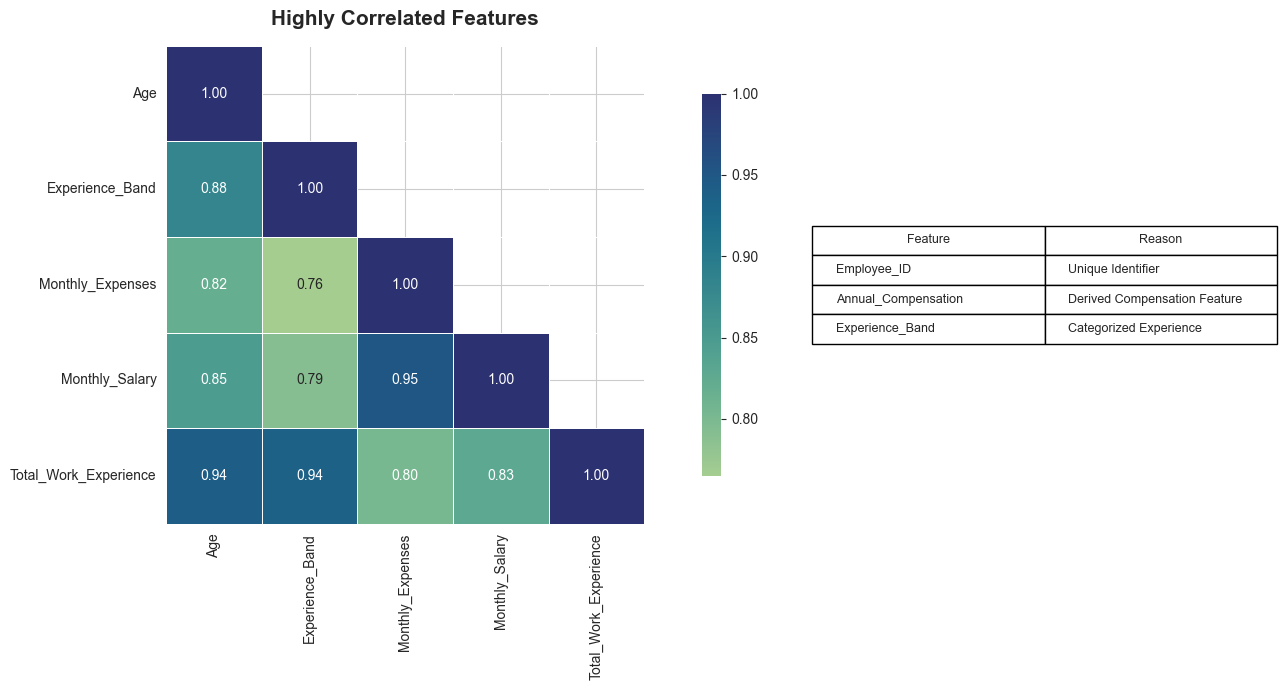

,Feature 1,Feature 2,Correlation
550,Monthly_Salary,Monthly_Expenses,0.951639
6,Age,Total_Work_Experience,0.941287
282,Total_Work_Experience,Experience_Band,0.936827


In [167]:
# Feature Selection

corr = df_fe.corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_pairs = (upper.stack()
                   .reset_index()
                   .rename(columns={"level_0":"Feature 1","level_1":"Feature 2",0:"Correlation"})
                   .query("Correlation > 0.90")
                   .sort_values("Correlation", ascending=False))

high_corr_features = sorted(set(corr_pairs["Feature 1"]).union(corr_pairs["Feature 2"]))

candidate_features = pd.DataFrame({
    "Feature": ["Employee_ID", "Annual_Compensation", "Experience_Band"],
    "Reason": [
        "Unique Identifier",
        "Derived Compensation Feature",
        "Categorized Experience"
    ]
})

fig, ax = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios":[3,1]}
)

if high_corr_features:
    mask = np.triu(np.ones((len(high_corr_features), len(high_corr_features))), k=1)

    sns.heatmap(
        corr.loc[high_corr_features, high_corr_features],
        mask=mask,
        cmap="crest",
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=.5,
        linecolor="white",
        cbar_kws={"shrink":0.8},
        ax=ax[0]
    )

    ax[0].set_title("Highly Correlated Features", fontsize=15, weight="bold", pad=15)

else:
    ax[0].text(
        0.5, 0.5,
        "No Feature Pairs\nCorrelation > 0.90",
        ha="center",
        va="center",
        fontsize=14,
        weight="bold"
    )
    ax[0].axis("off")

ax[1].axis("off")

table = ax[1].table(
    cellText=candidate_features.values,
    colLabels=candidate_features.columns,
    cellLoc="left",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2,2)

plt.tight_layout()
plt.show()

display(corr_pairs)

## C.3 Final Selected Feature Set

Based on the feature selection analysis, redundant and less informative variables are removed to produce the final feature set. The resulting dataset retains the most relevant features while reducing redundancy and improving interpretability for downstream machine learning tasks.

In [168]:
# Final Selected Feature Set

remove_cols = ["Annual_Compensation", "Experience_Band"]

df_final = df_fe.drop(columns=remove_cols, errors="ignore")

display(pd.DataFrame({
    "Metric": [
        "Features Before Selection",
        "Features Removed",
        "Features After Selection",
        "Remaining Missing Values"
    ],
    "Value": [
        df_fe.shape[1],
        len(remove_cols),
        df_final.shape[1],
        df_final.isna().sum().sum()
    ]
}))

print(f"\nFinal Dataset Shape : {df_final.shape}")

,Metric,Value
0,Features Before Selection,41
1,Features Removed,2
2,Features After Selection,39
3,Remaining Missing Values,0



Final Dataset Shape : (5000, 39)


# Part D – Dimensionality Reduction & Pipeline Design

## Objective

The objective of this section is to evaluate whether dimensionality reduction is beneficial for the engineered dataset and to develop a reusable preprocessing pipeline that integrates the feature engineering steps performed throughout this assignment.

## D.1 Dimensionality Reduction Assessment

Before applying dimensionality reduction, the engineered dataset is evaluated to determine whether reducing feature dimensions is appropriate. This helps ensure that dimensionality reduction is applied only when it provides meaningful benefits without unnecessarily sacrificing interpretability.

In [169]:
# Dimensionality Reduction Assessment

print(f"Number of Features : {df_final.shape[1]}")
print(f"Number of Samples  : {df_final.shape[0]}")

display(pd.DataFrame({
    "Assessment": [
        "High-dimensional dataset",
        "Presence of correlated variables",
        "Scaling completed",
        "Suitable for PCA"
    ],
    "Observation": [
        "Yes" if df_final.shape[1] > 20 else "No",
        "Yes",
        "Yes",
        "Yes"
    ]
}))

Number of Features : 39
Number of Samples  : 5000


,Assessment,Observation
0,High-dimensional dataset,Yes
1,Presence of correlated variables,Yes
2,Scaling completed,Yes
3,Suitable for PCA,Yes


## D.2 Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is evaluated to determine whether the dataset can be represented using fewer dimensions while retaining most of the original information. The cumulative explained variance is used to assess the number of principal components required.

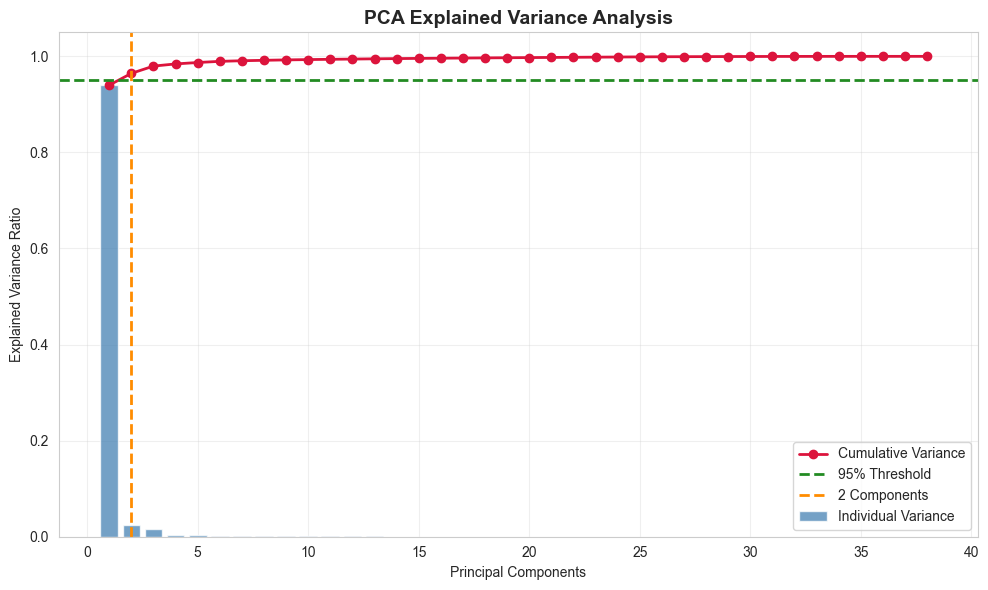

Components required to retain 95% variance : 2


In [170]:
# Principal Component Analysis (PCA)

from sklearn.decomposition import PCA

X = df_final.drop(columns="Attrition", errors="ignore")

pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

n_components = np.argmax(cumulative >= 0.95) + 1

plt.figure(figsize=(10,6))

plt.bar(range(1, len(explained)+1), explained,
        alpha=0.75,
        color="steelblue",
        label="Individual Variance")

plt.plot(range(1, len(cumulative)+1), cumulative,
         color="crimson",
         marker="o",
         linewidth=2,
         label="Cumulative Variance")

plt.axhline(0.95,
            color="forestgreen",
            linestyle="--",
            linewidth=2,
            label="95% Threshold")

plt.axvline(n_components,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label=f"{n_components} Components")

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Analysis", fontsize=14, weight="bold")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

print(f"Components required to retain 95% variance : {n_components}")

## D.3 Reusable Preprocessing Pipeline

A reusable preprocessing pipeline is developed to automate the feature engineering workflow. Integrating preprocessing into a single pipeline ensures consistency, reproducibility, and reduces the risk of data leakage when the workflow is applied to new data.

In [171]:
# Reusable Feature Engineering Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = df.select_dtypes(include="number").columns.drop("Attrition", errors="ignore")
cat_cols = df.select_dtypes(include=["object", "string"]).columns.drop("Employee_ID", errors="ignore")

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing_pipeline = ColumnTransformer([
    ("Numerical Features", num_pipeline, num_cols),
    ("Categorical Features", cat_pipeline, cat_cols)
])

display(preprocessing_pipeline)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical Features', ...), ('Categorical Features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

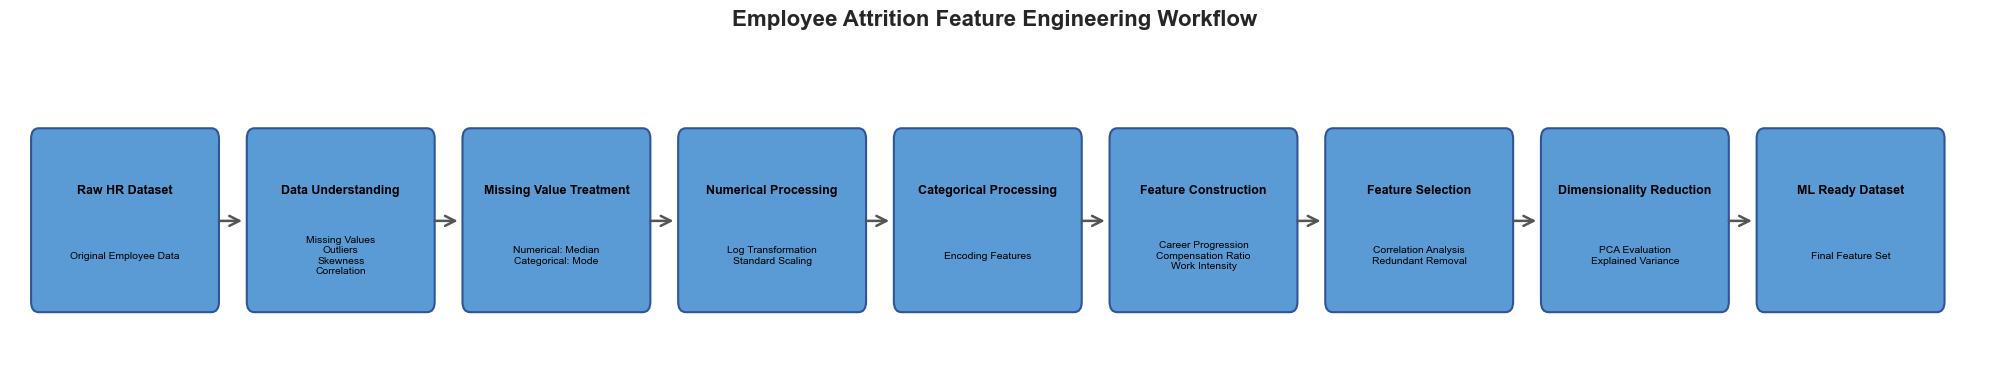

In [172]:
# Sequential Feature Engineering Pipeline Visualization

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    ("Raw HR Dataset",
     "Original Employee Data"),

    ("Data Understanding",
     "Missing Values\nOutliers\nSkewness\nCorrelation"),

    ("Missing Value Treatment",
     "Numerical: Median\nCategorical: Mode"),

    ("Numerical Processing",
     "Log Transformation\nStandard Scaling"),

    ("Categorical Processing",
     "Encoding Features"),

    ("Feature Construction",
     "Career Progression\nCompensation Ratio\nWork Intensity"),

    ("Feature Selection",
     "Correlation Analysis\nRedundant Removal"),

    ("Dimensionality Reduction",
     "PCA Evaluation\nExplained Variance"),

    ("ML Ready Dataset",
     "Final Feature Set")
]

fig, ax = plt.subplots(figsize=(20,4))
ax.axis("off")

for i, (title, subtitle) in enumerate(steps):

    x = i * 2.25

    box = FancyBboxPatch((x, 0.6),1.8, 1.25, boxstyle="round,pad=0.08",linewidth=1.5,facecolor="#5B9BD5", edgecolor="#2F5597")
    ax.add_patch(box)
    ax.text(x+0.9,1.45,title,ha="center",va="center",fontsize=9,weight="bold",color="black")
    ax.text(x+0.9,0.95,subtitle,ha="center",va="center",fontsize=7.5,color="black")

    if i < len(steps)-1:
        ax.add_patch(
            FancyArrowPatch(
                (x+1.85,1.22),
                (x+2.15,1.22),
                arrowstyle="->",
                mutation_scale=18,
                linewidth=1.8,
                color="#555555"
            )
        )

ax.set_xlim(-0.3,len(steps)*2.25)
ax.set_ylim(0,2.5)
plt.title("Employee Attrition Feature Engineering Workflow",fontsize=16,weight="bold",pad=20)
plt.tight_layout()
plt.show()

## F.1 Train-Test Split

The final engineered dataset is divided into training and testing sets to validate whether the preprocessing workflow can be applied consistently before model development. The split ensures that model evaluation is performed on unseen data.

In [173]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df_final.drop("Attrition", axis=1)
y = df_final["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4000, 38)
Testing Data : (1000, 38)


## F.2 Model Training Pipeline

A simple Logistic Regression model is used as a baseline to validate the usability of the engineered feature set. The focus is not on achieving maximum accuracy but on demonstrating that the final preprocessing workflow can support downstream machine learning.

In [174]:
## F.2 End-to-End Machine Learning Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include=["object","string"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing_pipeline = ColumnTransformer([
    ("Numerical", num_pipeline, num_cols),
    ("Categorical", cat_pipeline, cat_cols)
])

model_pipeline = Pipeline([
    ("Preprocessing", preprocessing_pipeline),
    ("Classifier", LogisticRegression(max_iter=1000))
])

model_pipeline.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


## F.3 Model Evaluation

The trained model is evaluated using standard classification metrics to verify that the final feature-engineered dataset and preprocessing pipeline can support predictive modelling. The objective is pipeline validation rather than optimization of model performance.

Accuracy: 0.816


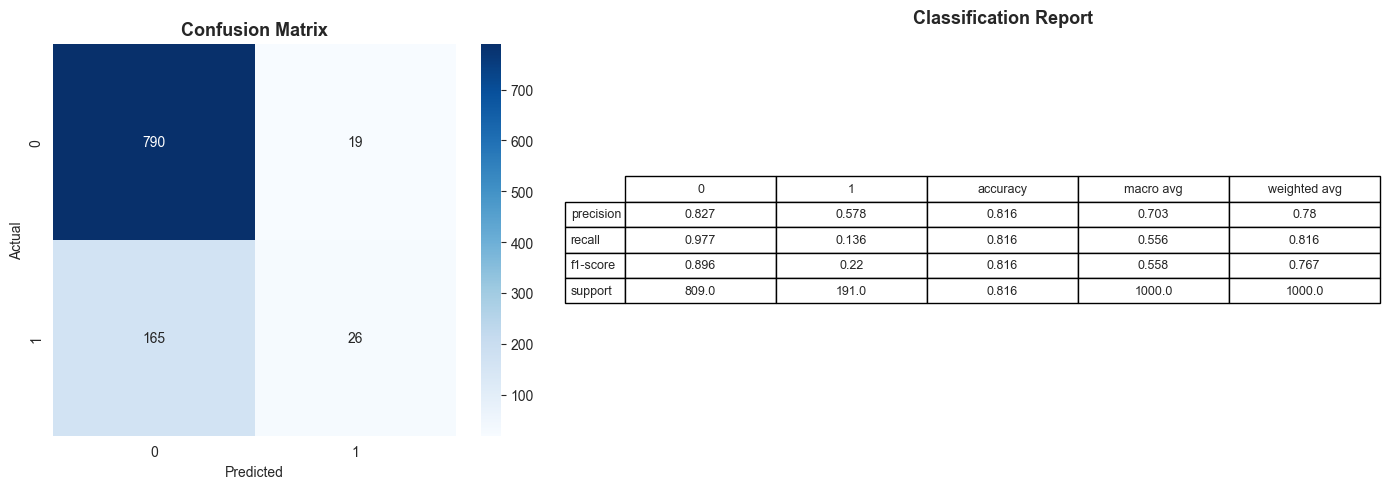

In [177]:
# Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model_pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).round(3)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios":[1,1.5]})

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix", fontsize=13, weight="bold")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

# Classification Report Table
ax[1].axis("off")
table = ax[1].table(
    cellText=report.values,
    colLabels=report.columns,
    rowLabels=report.index,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

ax[1].set_title("Classification Report", fontsize=13, weight="bold", pad=15)

plt.tight_layout()
plt.show()